In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a visually appealing style for the plots
sns.set_theme(style="whitegrid")

# Load the dataset from the CSV file
# The 'on_bad_lines' parameter skips any rows that have formatting errors
try:
    df = pd.read_csv('India_Strom_Dataset.csv', on_bad_lines='skip')
    print("Successfully loaded the dataset.")
except FileNotFoundError:
    print("Error: 'India_Strom_Dataset.csv' not found.")
    exit()

# --- Data Cleaning and Preparation ---

# Convert date columns to datetime objects for time-based analysis
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

# Extract the year from the start date to create a 'year' column
df['year'] = df['start_date'].dt.year

# Convert columns that should be numeric to a numeric type
# 'errors='coerce'' will turn any values that can't be converted into 'NaN' (Not a Number)
df['fatalities'] = pd.to_numeric(df['fatalities'], errors='coerce')
df['economic_loss_usd_m'] = pd.to_numeric(df['economic_loss_usd_m'], errors='coerce')
df['wind_speed_kmh'] = pd.to_numeric(df['wind_speed_kmh'], errors='coerce')
df['rainfall_mm'] = pd.to_numeric(df['rainfall_mm'], errors='coerce')

Successfully loaded the dataset.


/tmp/ipython-input-3475664354.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=storms_per_year.index, y=storms_per_year.values, palette='plasma')


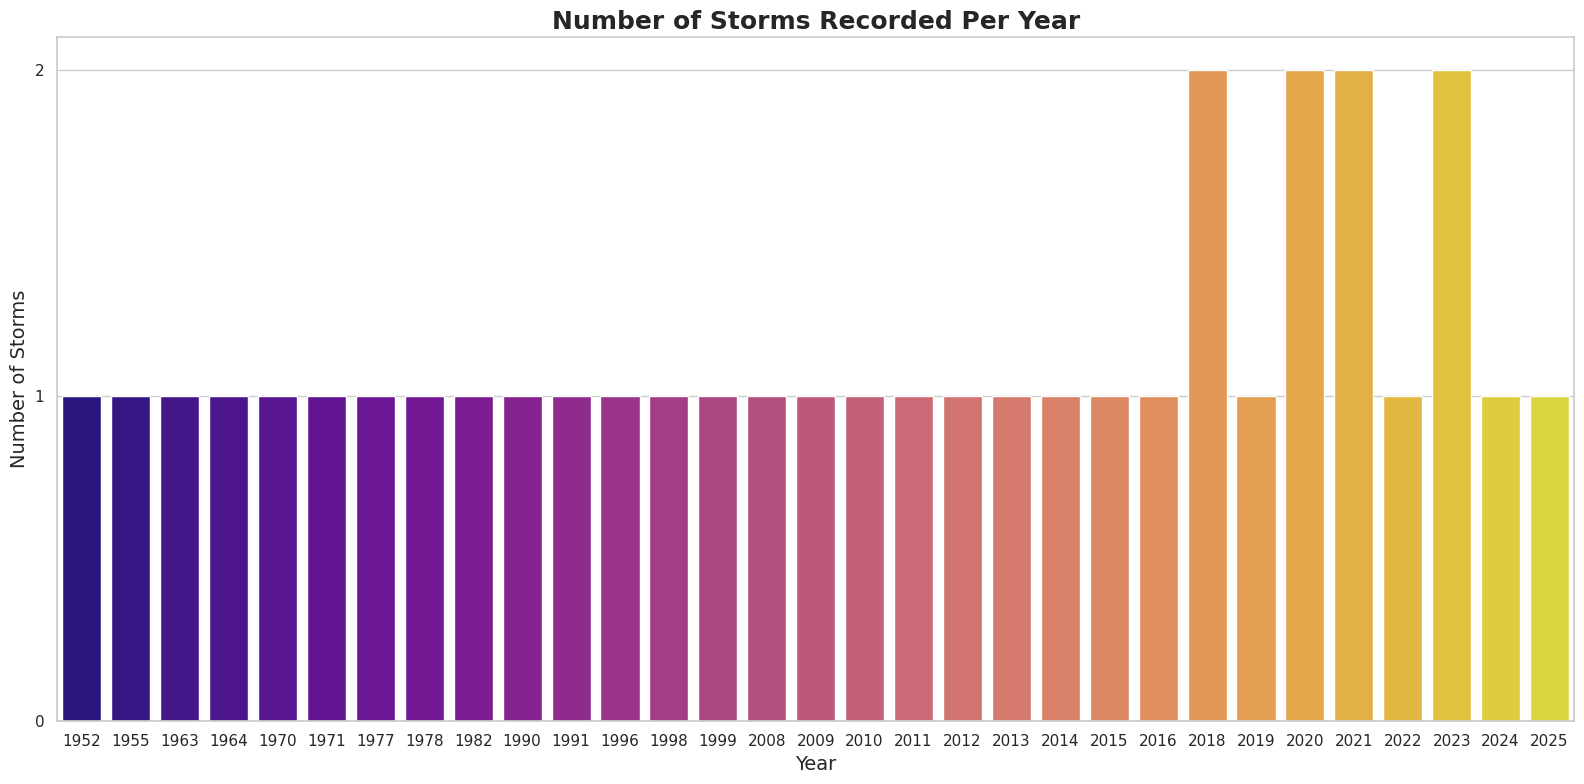

In [ ]:
# --- Data Aggregation ---
# Count the number of storms for each year and sort by year for a chronological x-axis
storms_per_year = df['year'].value_counts().sort_index()

# Find the maximum number of storms in a single year to set the y-axis limit
# Set a default if the series is empty to avoid errors
if not storms_per_year.empty:
    max_storms = storms_per_year.max()
else:
    max_storms = 1

# --- Visualization ---
# Set the figure size for a wider plot
plt.figure(figsize=(16, 8))

# Create the bar plot using a vibrant color palette
sns.barplot(x=storms_per_year.index, y=storms_per_year.values, palette='plasma')

# Add titles and labels for clarity
plt.title('Number of Storms Recorded Per Year', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Storms', fontsize=14)

# Set the y-axis ticks to increment by 1 (e.g., 0, 1, 2, 3...)
plt.yticks(np.arange(0, max_storms + 1, 1))

# Rotate the x-axis labels for better readability
plt.xticks(rotation=0, ha='center')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()


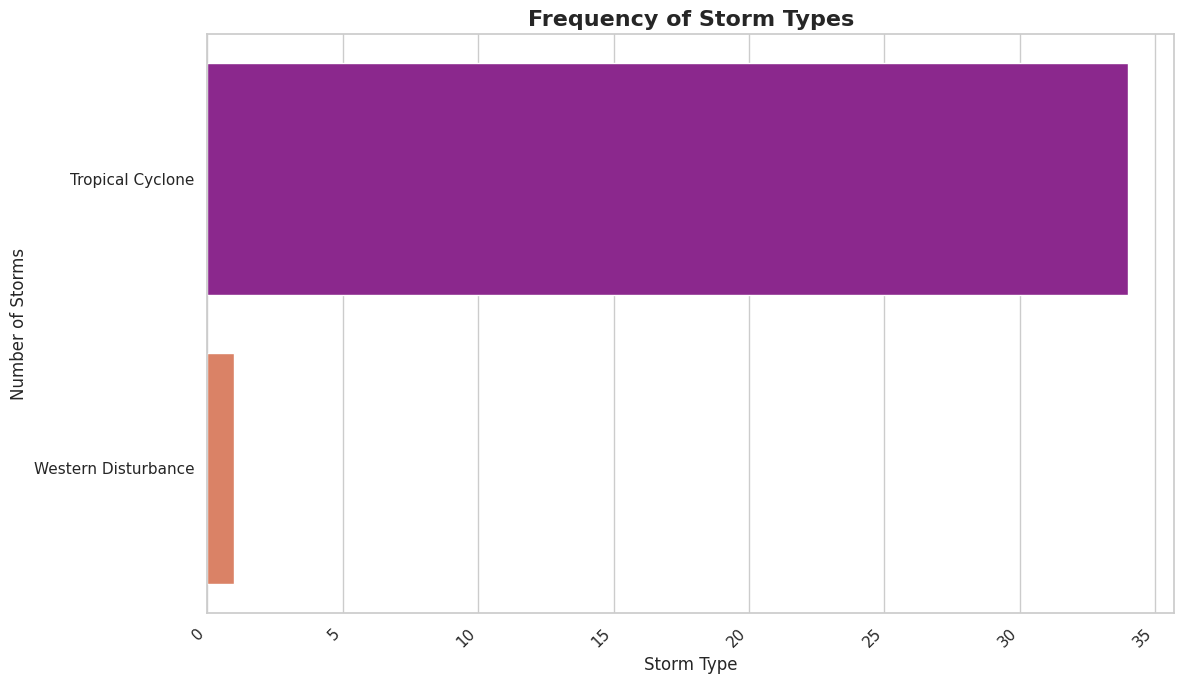

In [ ]:
# --- Visualization: Bar Chart with 'mako' Gradient ---
plt.figure(figsize=(12, 7))
storm_type_counts = df['storm_type'].value_counts()
sns.countplot(y='storm_type', data=df, palette='plasma', order=df['' \
''].value_counts().index, hue='storm_type', legend=False)
plt.title('Frequency of Storm Types', fontsize=16, fontweight='bold')
plt.xlabel('Storm Type', fontsize=12)
plt.ylabel('Number of Storms', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Adjusts plot to ensure everything fits without overlapping
plt.show()
# plt.subplot(3, 1, 2) # Create a subplot for the second plot
# sns.countplot(y='storm_type', data=df, palette='plasma', order = df['storm_type'].value_counts().index)
# plt.title('Distribution of Storm Types', fontsize=14, fontweight='bold')
# plt.xlabel('Count', fontsize=12)
# plt.ylabel('Storm Type', fontsize=12)

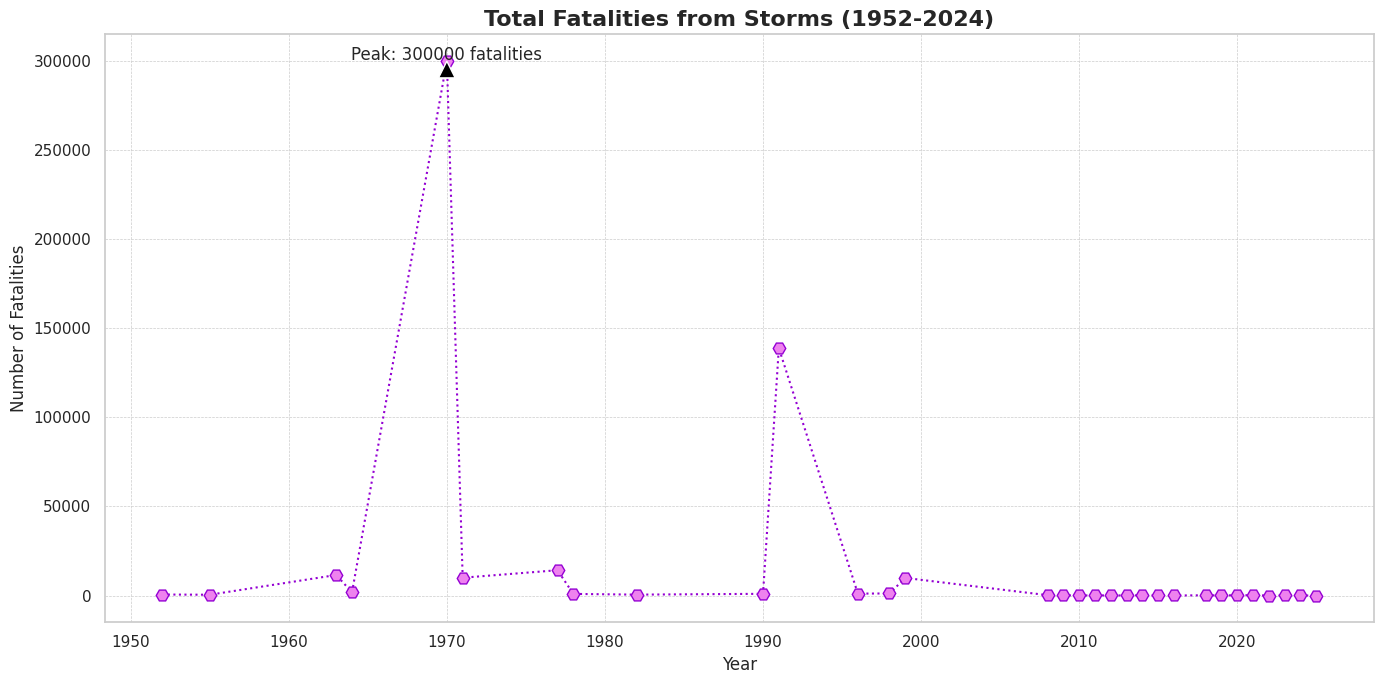

In [ ]:
# --- Visualization 2: Line Chart of Fatalities ---
plt.figure(figsize=(14, 7))
fatalities_by_year = df.groupby('year')['fatalities'].sum().dropna()
plt.plot(fatalities_by_year.index, fatalities_by_year.values, marker='H', linestyle=':', color='darkviolet', markersize=9, markerfacecolor='violet')
plt.title('Total Fatalities from Storms (1952-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Fatalities', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add an annotation for the year with the highest fatalities
max_fatality_year = fatalities_by_year.idxmax()
max_fatalities = fatalities_by_year.max()
plt.annotate(f'Peak: {int(max_fatalities)} fatalities', xy=(max_fatality_year, max_fatalities), xytext=(max_fatality_year, max_fatalities + 500),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center')
plt.tight_layout()
plt.show()



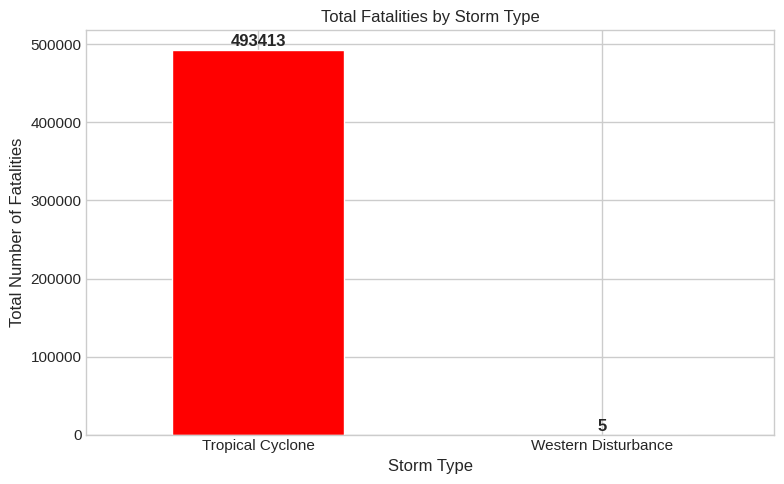

In [ ]:

# Filter for the two storm types of interest
storm_types_to_include = ['Tropical Cyclone', 'Western Disturbance']
filtered_df = df[df['storm_type'].isin(storm_types_to_include)].copy()
# Convert 'fatalities' to a numeric type, handling any non-numeric values
filtered_df['fatalities'] = pd.to_numeric(filtered_df['fatalities'], errors='coerce')
# Remove rows where 'fatalities' could not be converted
filtered_df.dropna(subset=['fatalities'], inplace=True)
# Group by storm type and calculate the total fatalities
fatalities_by_type = filtered_df.groupby('storm_type')['fatalities'].sum()

# Create a figure and axes for the plot
plt.figure(figsize=(8, 5))
ax = fatalities_by_type.plot(kind='bar', color=['red', 'skyblue'])
for i, v in enumerate(fatalities_by_type):
    # The text is placed at index `i`, with a slight vertical offset from the value `v`
    ax.text(i, v + 500, str(int(v)), ha='center', va='bottom', fontweight='bold')
plt.title('Total Fatalities by Storm Type')
plt.xlabel('Storm Type')
plt.ylabel('Total Number of Fatalities')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


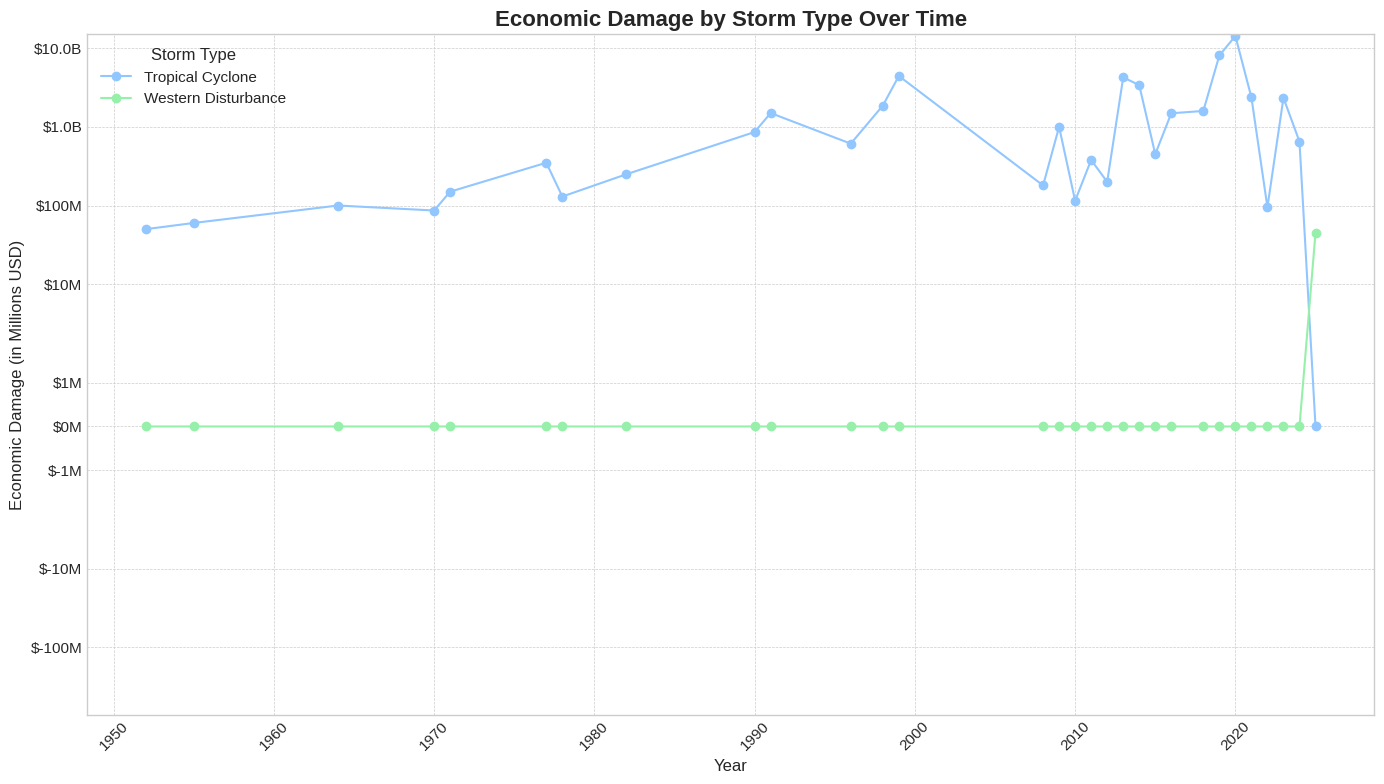

In [ ]:
# --- 2. DATA PREPARATION FOR VISUALIZATION ---
# Filter for only 'Tropical Cyclone' and 'Western Disturbance'
storm_types_to_include = ['Tropical Cyclone', 'Western Disturbance']
filtered_df = df[df['storm_type'].isin(storm_types_to_include)].copy()

# Convert date and economic loss columns to appropriate types
filtered_df['start_date'] = pd.to_datetime(filtered_df['start_date'], errors='coerce')
filtered_df['economic_loss_usd_m'] = pd.to_numeric(filtered_df['economic_loss_usd_m'], errors='coerce')

# Create a 'year' column from the start_date
filtered_df['year'] = filtered_df['start_date'].dt.year

# Drop rows where essential data is not available
filtered_df.dropna(subset=['year', 'economic_loss_usd_m'], inplace=True)
filtered_df['year'] = filtered_df['year'].astype(int)
# Group by year and storm type, then sum the economic damage
damage_over_time = filtered_df.groupby(['year', 'storm_type'])['economic_loss_usd_m'].sum().unstack().fillna(0)

# Set a visually appealing style for the plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))
for storm_type in damage_over_time.columns:
    plt.plot(damage_over_time.index, damage_over_time[storm_type], marker='o', linestyle='-', label=storm_type)
plt.title('Economic Damage by Storm Type Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Economic Damage (in Millions USD)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Storm Type', fontsize=11)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('symlog')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.1f}B' if x >= 1000 else f'${x:.0f}M'))
plt.tight_layout()
plt.show()
# Add a logarithmic scale to the y-axis for better visibility of smaller values
# Note: Using a log scale requires handling zero values. We'll plot from a small value instead.

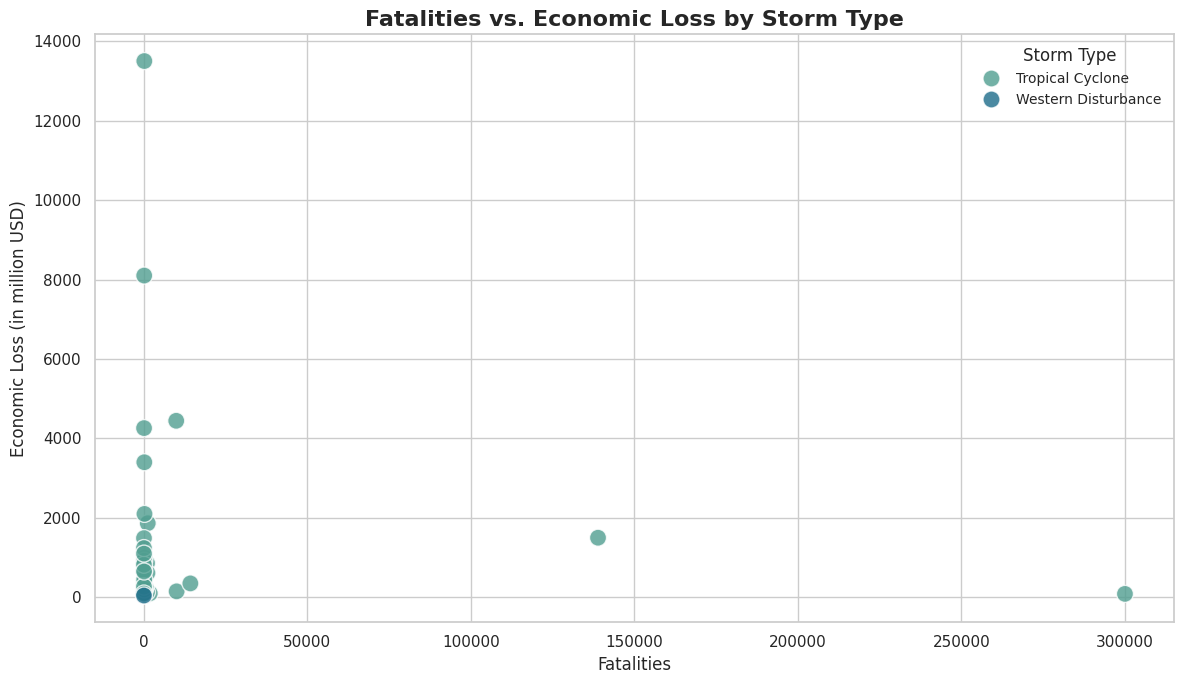

In [50]:
# --- Visualization ---
plt.figure(figsize=(12, 7))

# Create a cleaned dataframe, dropping rows where 'fatalities' or 'economic_loss_usd_m' is missing
df_cleaned = df.dropna(subset=['fatalities', 'economic_loss_usd_m'])

# Create the scatter plot with 'fatalities' on the x-axis
sns.scatterplot(data=df_cleaned, x='fatalities', y='economic_loss_usd_m', hue='storm_type', palette='crest', s=150, alpha=0.8)

# Update the title and labels for the new plot
plt.title('Fatalities vs. Economic Loss by Storm Type', fontsize=16, fontweight='bold')
plt.xlabel('Fatalities', fontsize=12)
plt.ylabel('Economic Loss (in million USD)', fontsize=12)
plt.legend(title='Storm Type', fontsize=10)
plt.tight_layout()
plt.savefig('fatalities_vs_economic_loss_xlimit.png')
plt.show()

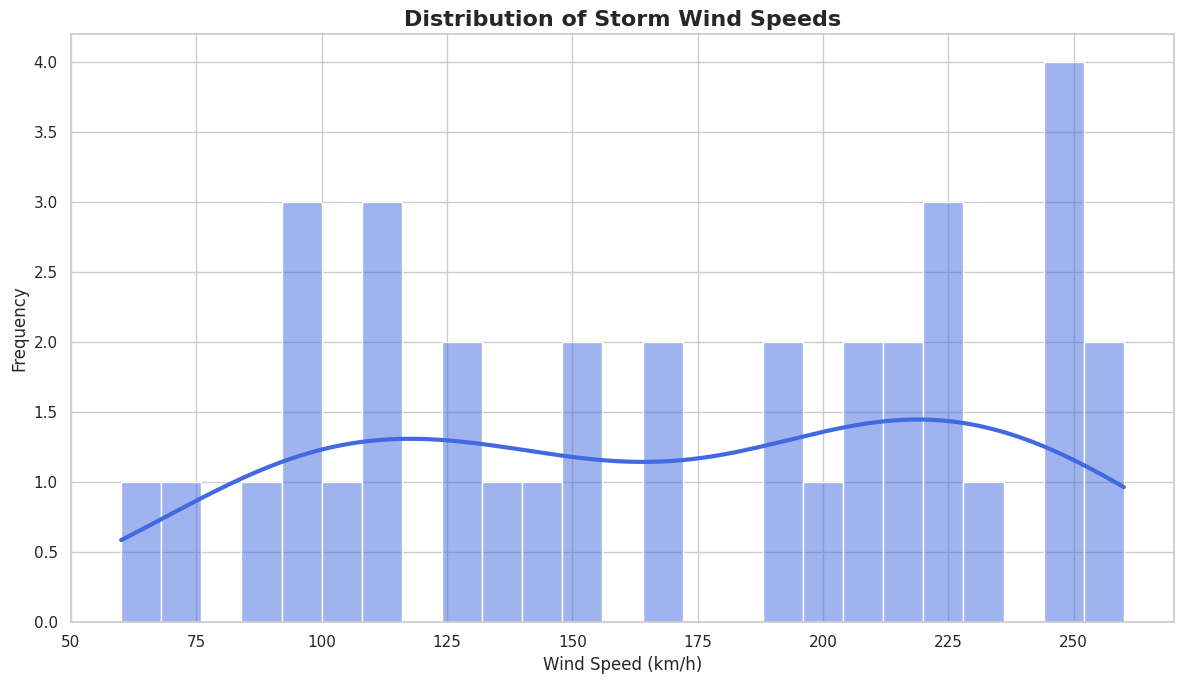

In [ ]:
 #--- Visualization 4: Histogram of Wind Speeds ---
plt.figure(figsize=(12, 7))
sns.histplot(df['wind_speed_kmh'].dropna(), bins=25, kde=True, color='royalblue', line_kws={'linewidth': 3, 'color': 'navy'})
plt.title('Distribution of Storm Wind Speeds', fontsize=16, fontweight='bold')
plt.xlabel('Wind Speed (km/h)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

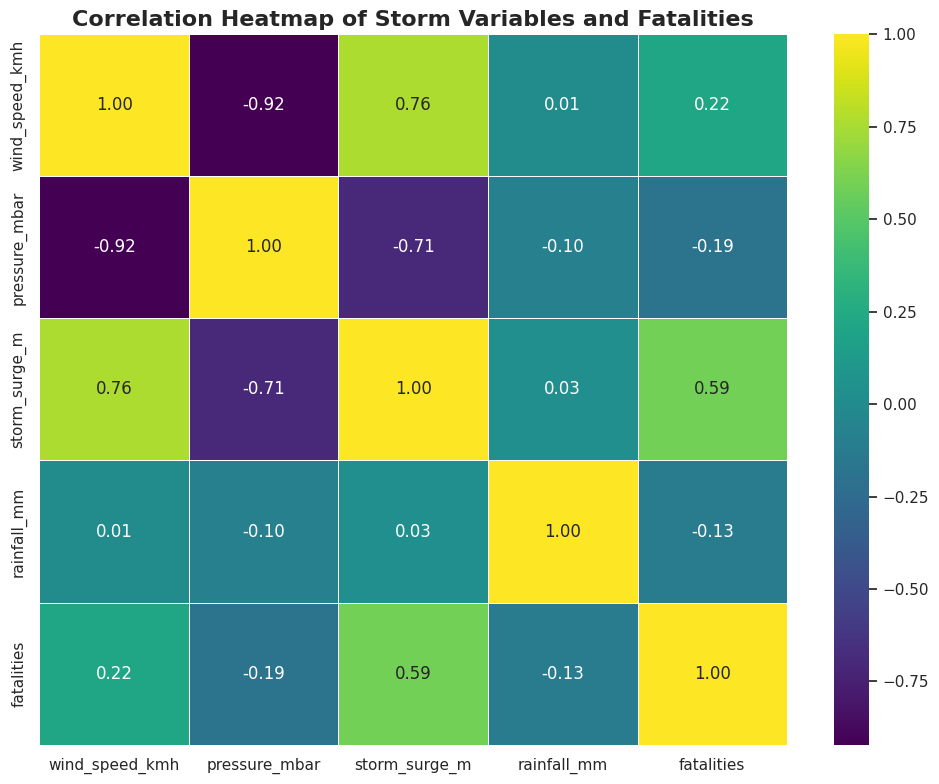

In [37]:
from sklearn.preprocessing import MinMaxScaler
# --- 1. Data Cleaning and Preparation ---
columns_to_plot = ['wind_speed_kmh', 'pressure_mbar', 'storm_surge_m', 'rainfall_mm', 'fatalities']
df_plot = df[columns_to_plot].copy()

# Convert all selected columns to numeric types, replacing non-numeric values with NaN
for col in df_plot.columns:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# Drop any rows that have missing values in any of the selected columns
df_plot.dropna(inplace=True)

# Reset the index to have a clean sequence for the x-axis
df_plot.reset_index(drop=True, inplace=True)

# --- 2. Data Normalization ---
# Set a professional plot style
sns.set_theme(style="whitegrid")

# Load the dataset, skipping any problematic lines
try:
    df = pd.read_csv('India_Strom_Dataset.csv', on_bad_lines='skip')
except FileNotFoundError:
    print("Error: 'India_Strom_Dataset.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# --- 1. Data Cleaning and Preparation ---
# Select the columns of interest
columns_for_corr = ['wind_speed_kmh', 'pressure_mbar', 'storm_surge_m', 'rainfall_mm', 'fatalities']
df_corr = df[columns_for_corr].copy()

# Convert all selected columns to numeric types, replacing non-numeric values with NaN
for col in df_corr.columns:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Drop any rows that have missing values to ensure accurate correlation calculation
df_corr.dropna(inplace=True)

# --- 2. Calculate Correlation Matrix ---
# Use the .corr() method to calculate the pairwise correlation of columns
correlation_matrix = df_corr.corr()

# --- 3. Visualization ---
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Storm Variables and Fatalities', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

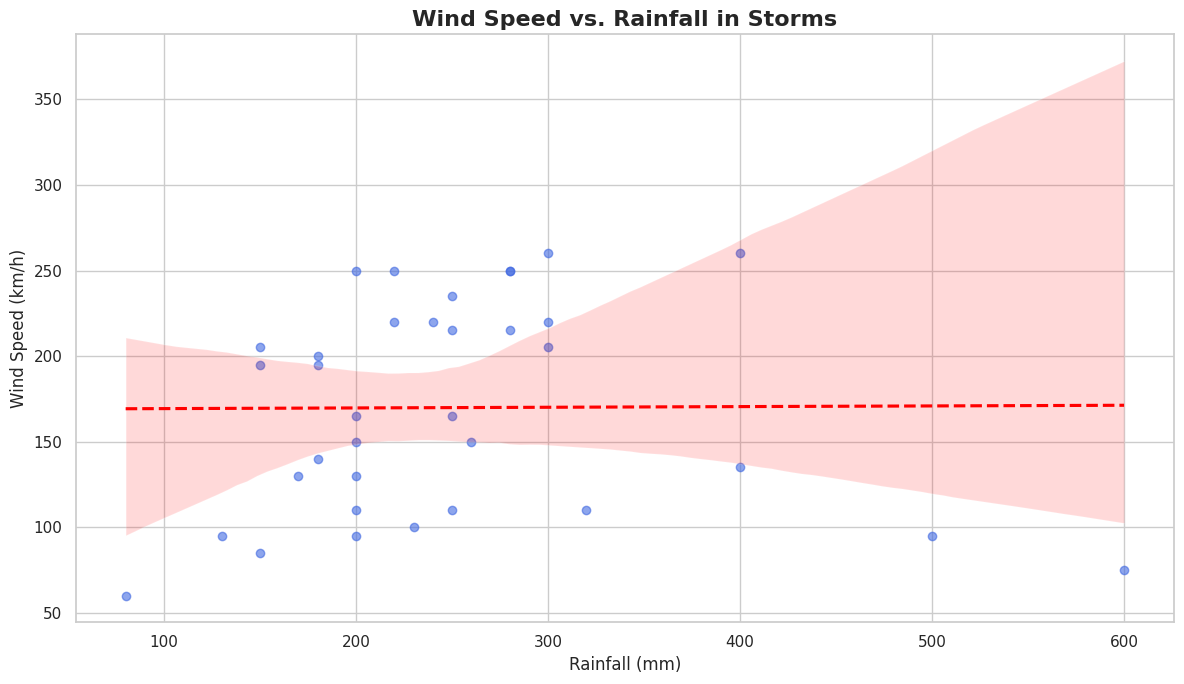

In [51]:
df['wind_speed_kmh'] = pd.to_numeric(df['wind_speed_kmh'], errors='coerce')
df['rainfall_mm'] = pd.to_numeric(df['rainfall_mm'], errors='coerce')

# --- Visualization ---
plt.figure(figsize=(12, 7))

# Create a cleaned dataframe, dropping rows where either variable is missing
df_cleaned = df.dropna(subset=['wind_speed_kmh', 'rainfall_mm'])

# Create a regression plot to show the scatter plot and the linear trend
sns.regplot(data=df_cleaned, x='rainfall_mm', y='wind_speed_kmh',
            scatter_kws={'alpha':0.6, 'color':'royalblue'},
            line_kws={'color':'red', 'linestyle':'--'})
plt.title('Wind Speed vs. Rainfall in Storms', fontsize=16, fontweight='bold')
plt.xlabel('Rainfall (mm)', fontsize=12)
plt.ylabel('Wind Speed (km/h)', fontsize=12)
plt.tight_layout()
plt.show()

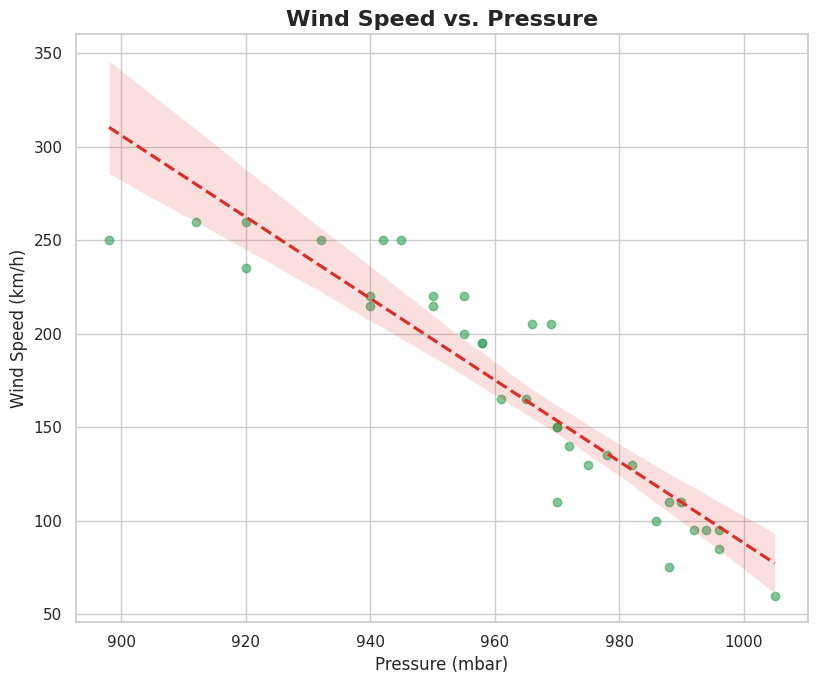

In [55]:
# --- Visualization for wind spped v/s pressure ---
plt.figure(figsize=(24, 7))
plt.subplot(1, 3, 2)
df_plot2 = df.dropna(subset=['pressure_mbar', 'wind_speed_kmh'])
sns.regplot(data=df_plot2, x='pressure_mbar', y='wind_speed_kmh',
            scatter_kws={'alpha':0.6, 'color':'#31a354'},
            line_kws={'color':'#de2d26', 'linestyle':'--'})
plt.title('Wind Speed vs. Pressure', fontsize=16, fontweight='bold')
plt.xlabel('Pressure (mbar)', fontsize=12)
plt.ylabel('Wind Speed (km/h)', fontsize=12)
plt.tight_layout()
plt.show()
#

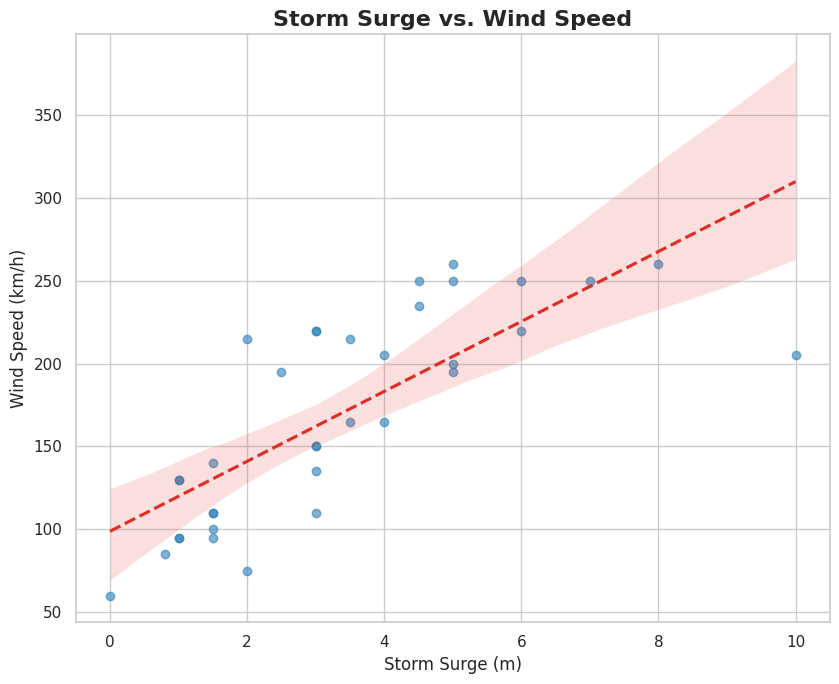

In [57]:
# --- Visualization with Subplots ---
plt.figure(figsize=(24, 7))

# --- Plot 1: Storm Surge vs. Wind Speed ---
plt.subplot(1, 3, 1)
df_plot1 = df.dropna(subset=['storm_surge_m', 'wind_speed_kmh'])
sns.regplot(data=df_plot1, x='storm_surge_m', y='wind_speed_kmh',
            scatter_kws={'alpha':0.6, 'color':'#2c7fb8'},
            line_kws={'color':'#de2d26', 'linestyle':'--'})
plt.title('Storm Surge vs. Wind Speed', fontsize=16, fontweight='bold')
plt.xlabel('Storm Surge (m)', fontsize=12)
plt.ylabel('Wind Speed (km/h)', fontsize=12)
plt.tight_layout()
plt.show()

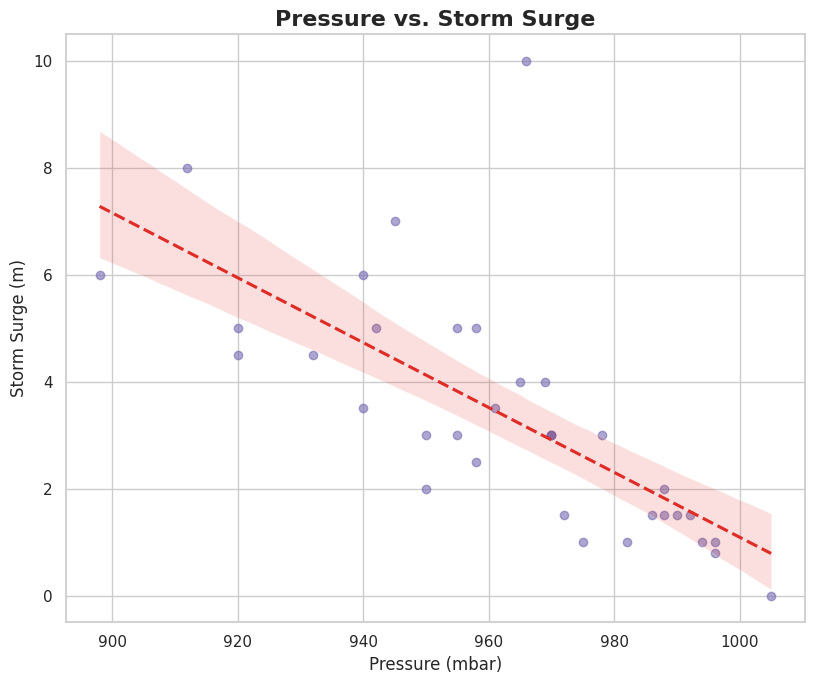

In [58]:
# --- Plot 3: Pressure vs. Storm Surge ---
plt.figure(figsize=(24, 7))
plt.subplot(1, 3, 3)
df_plot3 = df.dropna(subset=['pressure_mbar', 'storm_surge_m'])
sns.regplot(data=df_plot3, x='pressure_mbar', y='storm_surge_m',
            scatter_kws={'alpha':0.6, 'color':'#756bb1'},
            line_kws={'color':'#de2d26', 'linestyle':'--'})
plt.title('Pressure vs. Storm Surge', fontsize=16, fontweight='bold')
plt.xlabel('Pressure (mbar)', fontsize=12)
plt.ylabel('Storm Surge (m)', fontsize=12)
plt.tight_layout()
plt.show()

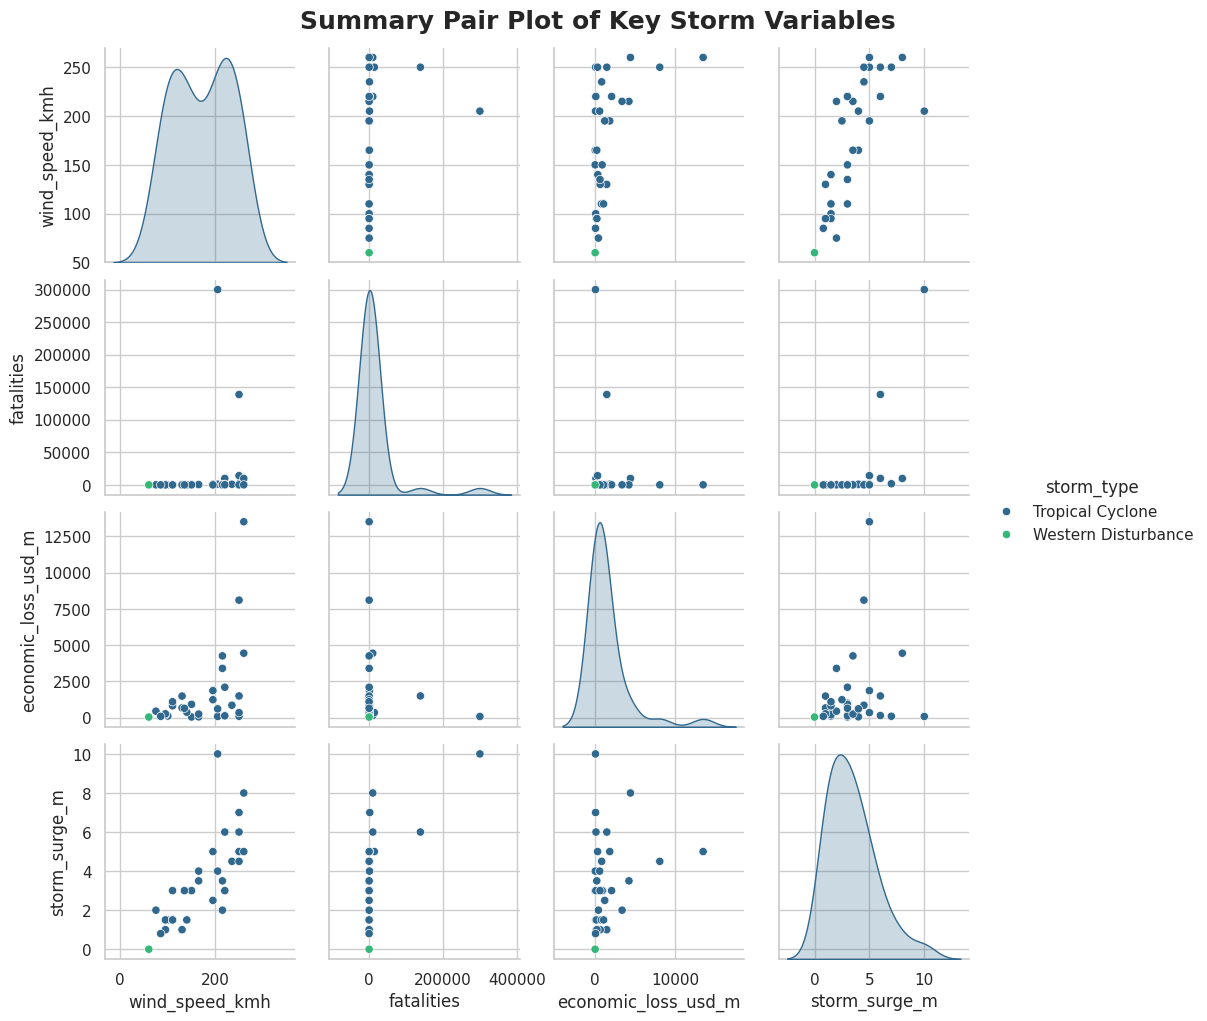

In [59]:
# --- Data Cleaning ---
# Select the most important columns for the summary plot
main_columns = [
    'wind_speed_kmh',
    'fatalities',
    'economic_loss_usd_m',
    'storm_surge_m',
    'storm_type'
]
df_summary = df[main_columns].copy()

# Convert numeric columns, coercing errors
for col in df_summary.columns:
    if col != 'storm_type':
        df_summary[col] = pd.to_numeric(df_summary[col], errors='coerce')

# Drop rows with any missing values in these key columns
df_summary.dropna(inplace=True)

# --- Visualization ---
# Create the pair plot, coloring by 'storm_type'
# The 'diag_kind="kde"' creates a smooth density plot on the diagonal
pairplot_fig = sns.pairplot(df_summary, hue='storm_type', palette='viridis', diag_kind='kde')
pairplot_fig.fig.suptitle('Summary Pair Plot of Key Storm Variables', y=1.02, fontsize=18, fontweight='bold')
plt.show()